Algoritmo de agrupamiento K-means
===

* *30 min*

Las técnicas de agrupamiento se utilizan para dividir un conjunto de datos en grupos de características homogéneas. Las aplicaciones a nivel organizacional incluyen la detección del tipo de clientes, la obtención de series de comportamiento similar en diferentes tipos de mercados, caracterización de fuerzas de venta, y la detección del tipo de productos similares. En este tutorial se aborda el algoritmo [K-means](https://es.wikipedia.org/wiki/K-medias), el cuál es uno de los más conocidos tanto en el área de estadística como de aprendizaje automático.

Al finalizar este tutorial, usted estará en capacidad de:

* Definir si un problema puede ser resuelto usando algoritmos de agrupmaiento.


* Describir el funcionamiento del algoritmo K-means.


* Definir las principales métricas de distancia.


* Explicar que factores afectan los resultados obtenidos mediante algoritmos de agrupamiento.


* Usar el lenguaje R para obtener realizar el agrupamiento de datos.

## Definición del problema

Se desea detectar los tipos de clientes existentes en una empresa con el fin de poder definir políticas para su manejo en una etapa posterior.

Se tienen 60 observaciones para las variables $x_1$ y $x_2$ las cuales podrían ser utilizadas para caracterizar los clientes. En términos de los datos, se desea determinar si existen grupos de comportamento homogéneo.

In [3]:
## 
## Datos
##
x1 <- c(10.67,  9.74, 10.23, 11.17, 10.41, 11.14, 10.12,  9.58, 11.16, 10.08,
         9.96,  9.17, 11.52, 11.27,  8.72, 11.30,  9.70,  8.69, 10.99, 10.82,
        10.87, 11.95, 12.77, 13.25, 14.42, 16.03, 12.23, 13.24, 10.88, 15.85,
        11.63, 13.41, 11.71, 12.49, 14.46, 15.00, 12.24, 13.68, 15.06, 12.78,
        13.27, 14.40, 14.50, 14.20, 14.62, 13.05, 14.43, 13.51, 14.63, 15.36,
        14.24, 13.82, 14.52, 15.43, 14.58, 12.87, 15.37, 15.61, 15.12, 13.64)

x2 <- c(14.70, 13.79, 14.30, 15.53, 15.08, 14.45, 12.95, 13.76, 15.21, 13.53,
        13.31, 12.41, 16.01, 15.41, 11.66, 15.11, 13.56, 11.81, 16.28, 14.41,
         6.91,  6.05,  7.97,  8.03,  9.25,  9.88,  6.97,  8.58,  6.15,  9.51,
         7.28,  8.35,  6.37,  7.60,  8.21,  10.11, 7.16,  8.12,  8.47,  8.74,
        13.92, 16.58, 17.39, 16.70, 17.22, 12.20, 16.31, 15.12, 17.00, 16.95,
        17.55, 15.46, 18.90, 19.00, 17.01, 14.26, 18.91, 19.00, 17.84, 15.49)

d <- data.frame(x1=x1, x2=x2)
head(d)

x1,x2
10.67,14.70
9.74,13.79
10.23,14.30
11.17,15.53
10.41,15.08
11.14,14.45


## Solución

### Definición metamática del problema de agrupameinto

Este es el problema inverso al de clasificación. En la siguiente figura se desea determinar cuántos grupos existen en un conjunto de datos y los centroides de dichos grupos, tal que los miembros de cada grupo tengan unas características similares. El centroide de cada grupo representa a los miembros de su grupo.   

![agrupamiento-1.jpg](images/agrupamiento/agrupamiento-1.jpg)

Nóte que en este ejemplo resulta fácil de visualizar ya que es un problema de dos dimensiones. En la realidad esto es completamente inusual y no hay una forma simple de detectar los grupos visualmente.

### Algoritmo K-means

El algoritmo K-means se basa en asignar $n$ ejemplos a uno de $K$ grupos posibles. La notación usada es la siguiente:


* $\mathbf{x}_i$ representa el punto $i$ de la figura.


* $x_{ij}$ representa las componentes del punto $\mathbf{x}_i$, con $j=1,...,P$. En términos de la figura, $x_{11}$ representa la coordenada en el eje X del punto 1, mientras que $x_{12}$ representa la coordenada del eje Y del punto 1.


* $P$ es el número de dimensiones (cantidad de variables).


* $S_k$ representa el conjunto de puntos pertenecientes al grupo $k$.


* La pertenencia del punto (patrón o ejemplo) $\mathbf{x}_i$ al grupo $S_k$ se representa como $\mathbf{x}_i \in S_k$. 


* $\mathbf{u}_k$ representa el centro del grupo $k$, con componentes $u_{kj}$; $j=1,...,P$ y $k=1,...,K$. Para el ejemplo presentado, $u_{11}$ es la coordenada en X del centroide 1, $u_{12}$ es la coordenada en Y del centroide 1, $u_{21}$ es la coordenada en X del centroide 2, y así sucesivamente. 


El algoritmo asigna el punto $\mathbf{x}_i$ al grupo cuyo centroide $\mathbf{u}_k$ es más cercano. Si se tienen tres grupos ($K=3$), con los siguientes centroides (representados por los rectángulos), entonces, los puntos $\mathbf{x}_i$ serían asignados a cada grupo de la siguiente forma:

![agrupamiento-2](images/agrupamiento/agrupamiento-2.jpg)

En el algoritmo K-means, se pretende minimizar la distancia entre los puntos que pertenecen a cada grupo y maximizar la distancia entre grupos.  Para ello, en este algoritmo se minimiza:

$$ \sum_{i=1}^k \sum_{\mathbf{x}_j \in S_i} \text{dist}( \mathbf{x}_j, \mathbf{u}_i)$$


Si se usa la norma euclidiana:

$$ \text{dist}( \mathbf{x}_j, \mathbf{u}_i) = \| \mathbf{x}_j - \mathbf{u}_i \|^2 = \sum_{p=1}^P (x_{jp} - u_{ip})^2$$

Este proceso se realiza en dos fases:


* Paso 1: Dados los centros de los clusters $\mathbf{u}_i$, cada punto $\mathbf{x}_j$ se asigna al cluster más cercano. En esta fase se asignan todos los puntos de la muestra de datos a un cluster.


* Paso 2: Se recalcula cada centroide $\mathbf{u}_i$ como el promedio de los puntos $\mathbf{x}_j$ que pertenecen a él; es decir, la componente $u_{ip}$ del centroide $i$ es el promedio de las componentes $x_{jp}$. 


El algoritmo se detiene cuando ningún punto cambia de cluster. Este caso es ejemplificado en la siguiente figura.

![agrupamiento-3](images/agrupamiento/agrupamiento-3.jpg)

## Métricas de distancia

Existen distintas métricas para computar la distancia entre puntos. 

**Euclidiana.** 

$$ \text{dist}(\mathbf{x}_i, \mathbf{x}_j) =\left\{ \sum_k (x_{ik} - x_{jk})^2 \right\}^\frac{1}{2}$$

**Manhattan.**

$$ \text{dist}(\mathbf{x}_i, \mathbf{x}_j) = \sum_k \left|x_{ik} - x_{jk}\right| $$


**Chebychev**.

$$ \text{dist}(\mathbf{x}_i, \mathbf{x}_j) = \max_k \left|x_{ik} - x_{jk}\right| $$




### Agrupamiento usando el lenguaje R

In [5]:
##
## Computa los centro para tres clusters
##
clusters <- kmeans(d, 3)

##
## Número de ejemplos en cada cluster
##
str(clusters$size)

 int [1:3] 17 23 20


In [6]:
##
## Centros de cada cluster
##
clusters$centers

x1,x2
14.58706,17.20176
10.67957,14.07174
13.19750,7.98550


In [11]:
##
## Cluster al que pertence cada patrón
##
head(clusters$cluster)

[1] 2 2 2 2 2 2

In [12]:
##
## Agrega el cluster al data.frame
## de datos originales
##
d$cluster = clusters$cluster
head(d)

In [13]:
##
## Promedio de x1 por cluster
##
aggregate(data = d, x1 ~ cluster, mean)

cluster,x1
1,14.58706
2,10.67957
3,13.19750


In [14]:
##
## Promedio de x2 por cluster
##
aggregate(data = d, x2 ~ cluster, mean)

cluster,x2
1,17.20176
2,14.07174
3,7.98550


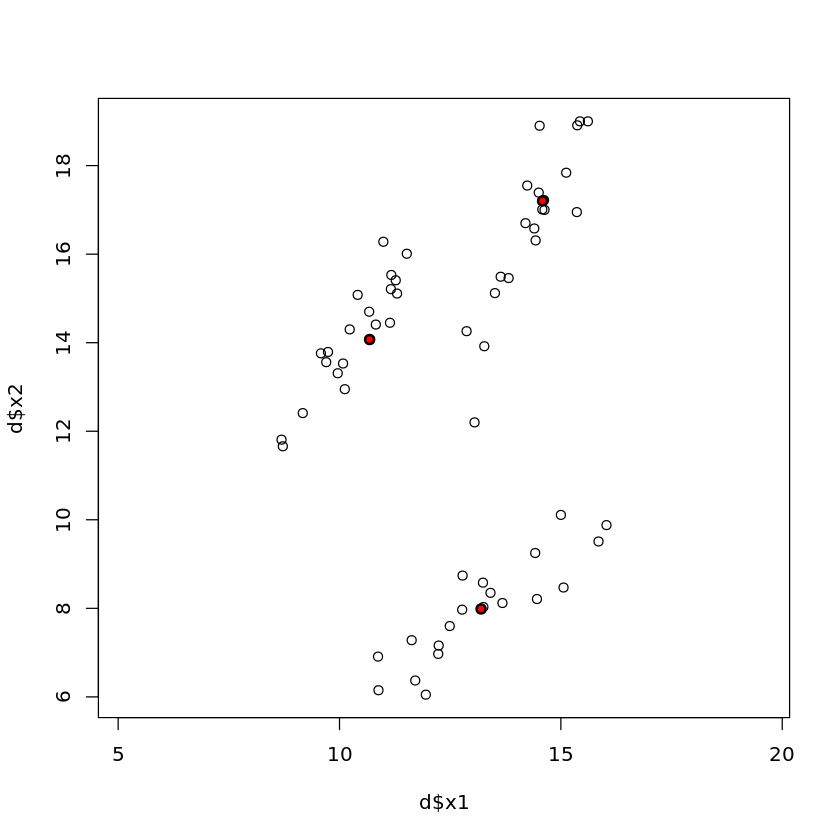

In [41]:
##
## Grafica los datos como puntos y
## los centros de los clusters
##
plot(d$x1, d$x2, type = 'p', asp=1)
points(clusters$centers[1:3,1], 
       clusters$centers[1:3,2], 
       pch=21, bg='red', lwd=2)

### Escalamiento y transformación de variables

El algoritmo K-means se ve afectado por la escala de las variables. Por ello, se debe realizar la transformación de las variables antes de aplicar K-means. En las siguientes ecuaciones, $x$ representa cualquiera de las componentes de $\mathbf{x}$.

**Normalización max-min.** 

$$x_* = \frac{x-\min(x)}{\max(x) - \min(x)}$$

**Estandarización z-score.**

$$z_* = \frac{x-\mu_x}{\sigma_x}$$

* $\mu_x$ es la media de $x$.
* $\sigma_x$ es la desviación estándar de $x$.

**Variables nominales.** Una variable nominal con categorías $C_1$, $C_2$, ..., $C_n$ se codifica con $n-1$ niveles, $L_i$, $i=1,...,n-1$:

$$ L_i =
   \begin{cases}
      1, & \text{if $\mathbf{x} \in C_i$.} \\
      0, &\text{En caso contrario.}
   \end{cases}
$$


Si las categorías están ordenadas se codifica como:

$$ L_i =
   \begin{cases}
      i, & \text{if $\mathbf{x} \in C_i$.} \\
      0, &\text{En caso contrario.}
   \end{cases}
$$

y luego es realiza la normalización.

### Ejemplo

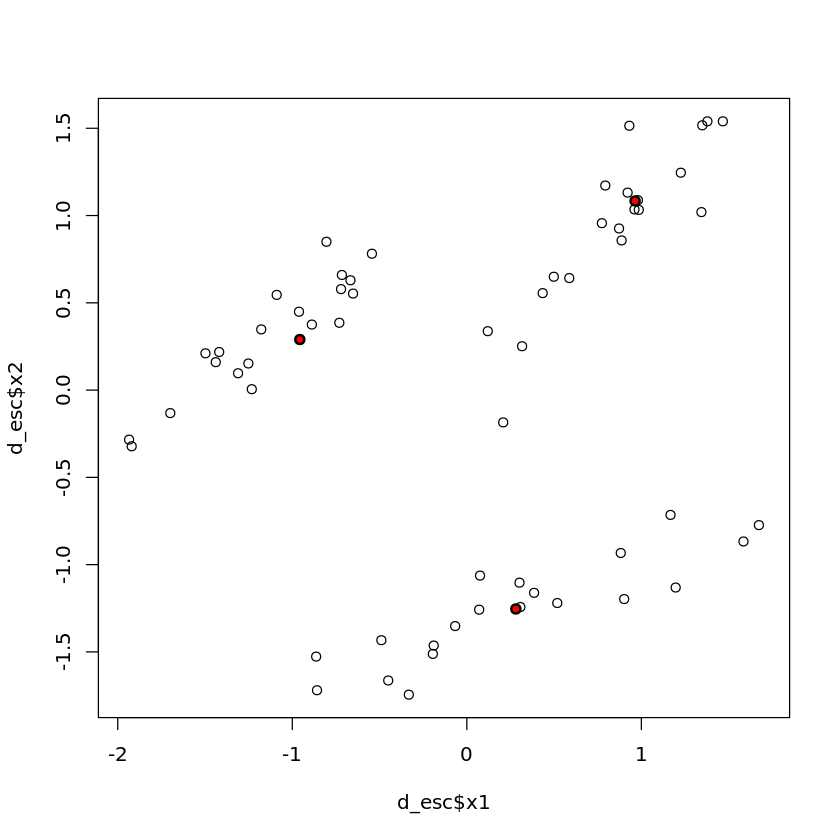

In [42]:
##
## Se escalan los datos
##
d_esc <- as.data.frame(lapply(d, scale))

##
## Computa los centro para tres clusters
##
clusters <- kmeans(d_esc, 3)

##
## Grafica los datos como puntos y
## los centros de los clusters
##
plot(d_esc$x1, d_esc$x2, type = 'p', asp=1)
points(clusters$centers[1:3,1], 
       clusters$centers[1:3,2], 
       pch=21, bg='red', lwd=2)

### Otras técnicas de agrupamiento

#### Clustering Jerárquico Divisivo

El algoritmo se inicia con un solo cluster que contiene todos los datos. Cada cluster es dividido recursivamente en dos clusters de máxima disimilitud. El algoritmo finaliza cuando hay un cluster por cada observación.

#### Clustering Jerárquico Aglomerativo

En esta algoritmo, cada cluster contiene un solo dato. 

1. Se calcula la métrica de distancia entre todos los clusters.

2. Se unen los dos clusters con menor distancia en uno solo.

3. Se retorna al paso 1.

El algoritmo se detiene cuando se llegue a un solo cluster que contiene todos los datos.

#### Bisecting K-means

Este es un procedimiento constructivo a medias entre el agrupamiento jerárquico y K-means. El algoritmo se inicia con un solo cluster que contiene todos los datos y se ejecuta de la siguiente forma:

1. Se selecciona un cluster para dividir.

2. Se divide el cluster seleccionado en dos clusters usando K-means. Este es el paso de bisección.

3. Repita el paso 2 por un número fijo de veces y seleccione la partición con la mejor métrica de desempeño.

4. Repita los pasos 1, 2 y 3 hasta alcanzar el número deseado de clusters.



#### K-medoids

En esta variación del algoritmo, los centros (medoids) de cada cluster son puntos de la muestra de datos; esto es, el centro de cada cluster es uno de los puntos asignados al cluster. El algoritmo opera de forma similar a K-means:

* Paso 1: Se seleccionan $k$ puntos como centros de los clusters.

* Paso 2: Para todos los clusters se verifica si alguno de los miembros del cluster disminuye la métrica de distancia utilizada. En caso afirmativo, este punto pasa a ser el nuevo centro del cluster. En caso negativo, hay convergencia del algoritmo.

* Paso 3: Se asignan los puntos al cluster con centro más cercano y se retorna al Paso 2. 

#### K-means++

Este algoritmo es similar al algoritmo K-means, con la diferencia que los nuevos centros de los clusters son generados de forma aleatoria.

#### Mini batch K-means

Este método se basa en tomar un subconjunto de los datos disponibles para estimar los clusters. Se usa para grandes conjuntos de datos.

Para un número $T$ de iteraciones y unos centros iniciales aleatorios se realiza el siguiente procedimiento:

1. Se seleccionan $b$ puntos aleatoriamente del conjunto de datos.

2. Se asignan los puntos a los clusters actuales como en K-means.

3. Por cada uno de los $b$ puntos se ajusta el centro del correspondiente cluster uno a uno.

Este algoritmo usa una regla de ajuste similar a la regla de aprendizaje del perceptrón.

---